# 00 · Negocio y viabilidad de DiputadoDetector

En este notebook justificamos **por qué** construimos DiputadoDetector y **si tiene sentido económico**.
Cubrimos el bloque 4.1 del enunciado: problema, público objetivo, propuesta de valor, viabilidad técnica
y económica (costes de inferencia, latencia, regulación y monetización).

Todas las cifras de mercado son **órdenes de magnitud** tomados de informes públicos (indicamos la fuente);
las cifras técnicas (latencia y consumo) las **medimos nosotros** en el notebook 06 y las leemos de
`artifacts/benchmarks.json`. Si ese fichero no existe todavía, usamos valores provisionales y lo indicamos.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

from diputado import config

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(config.BRAND_NAME, "·", config.BRAND_TAGLINE)

DiputadoDetector · Detector de estafas multimodal


## 1. El problema

El fraude por **suplantación** (el falso banco que llama, el SMS de Correos con una tasa de 1,99 €, el
«hola mamá, este es mi número nuevo», las inversiones milagro en cripto) tiene tres rasgos que motivan
nuestro producto:

1. **Es multimodal por naturaleza.** La misma campaña llega por voz (llamada o nota de audio), por imagen
   (captura de un SMS, una carta en papel) y por texto. Un filtro que solo lee texto no ve una llamada,
   y uno que solo escucha no ve el enlace del SMS que la acompaña.
2. **Ataca a la persona, no al sistema.** En el fraude de pago autorizado (APP fraud) es la propia víctima
   quien autoriza la transferencia o dicta el código. Los controles técnicos del banco (3-D Secure, OTP)
   no sirven si el cliente entrega el código voluntariamente.
3. **Se concentra en colectivos vulnerables**, en particular personas mayores con menos experiencia
   digital, que necesitan una explicación clara y en voz alta, no un número de riesgo.

Además el contexto regulatorio está cambiando: el Reglamento europeo de Servicios de Pago (PSR, en
tramitación junto a PSD3) contempla que el banco **reembolse** a la víctima en ciertos casos de
suplantación del propio banco. El coste del fraude pasa del cliente al banco, y con él el incentivo
para prevenirlo.

In [2]:
mercado = pd.DataFrame([
    {"Indicador": "Fraude en pagos en el EEE (2022)", "Orden de magnitud": "≈ 4.300 M€ / año",
     "Fuente": "EBA y BCE, Report on payment fraud (2024)"},
    {"Indicador": "Ciberdelitos conocidos en España (2023)", "Orden de magnitud": "≈ 470.000, de los que ≈ 9 de cada 10 son estafas",
     "Fuente": "Ministerio del Interior, Balance de Criminalidad 2023"},
    {"Indicador": "Fraude de pago autorizado en Reino Unido (2023)", "Orden de magnitud": "≈ 460 M£ / año",
     "Fuente": "UK Finance, Annual Fraud Report 2024"},
    {"Indicador": "Población española de 65 años o más", "Orden de magnitud": "≈ 20 % (≈ 9,9 M de personas)",
     "Fuente": "INE, Estadística Continua de Población (2024)"},
])
display(mercado.style.hide(axis="index").set_caption("Contexto de mercado (órdenes de magnitud)"))

Indicador,Orden de magnitud,Fuente
Fraude en pagos en el EEE (2022),≈ 4.300 M€ / año,"EBA y BCE, Report on payment fraud (2024)"
Ciberdelitos conocidos en España (2023),"≈ 470.000, de los que ≈ 9 de cada 10 son estafas","Ministerio del Interior, Balance de Criminalidad 2023"
Fraude de pago autorizado en Reino Unido (2023),≈ 460 M£ / año,"UK Finance, Annual Fraud Report 2024"
Población española de 65 años o más,"≈ 20 % (≈ 9,9 M de personas)","INE, Estadística Continua de Población (2024)"


## 2. Público objetivo: B2B2C

Consideramos tres modelos y elegimos **B2B2C**:

| Opción | Ventaja | Problema | Decisión |
|---|---|---|---|
| B2C (app para el ciudadano) | Contacto directo con la víctima | Coste de adquisición altísimo; la gente no instala apps «por si acaso» | Descartado |
| B2B puro (herramienta para el equipo de fraude) | Venta clara | No llega al momento crítico: cuando el cliente está al teléfono | Parcial |
| **B2B2C (el banco lo integra en su app)** | El banco ya tiene al cliente, la confianza y el incentivo (PSR) | Ciclo de venta largo | **Elegido** |

Por eso la aplicación tiene **dos vistas**: la del *cliente* (semáforo, voz, infografía, vídeo para la
familia) y la del *analista del banco* (traza auditable, campañas, consultas en lenguaje natural).

In [3]:
canvas = {
    "Problema": "Estafas por suplantación que llegan por voz, imagen y texto; las víctimas entregan códigos y transfieren dinero.",
    "Segmentos": "Bancos y cooperativas de crédito (pagador). Sus clientes, especialmente mayores de 60 (usuario).",
    "Propuesta de valor": "«Antes de pagar o dar un código, pregúntanos»: veredicto explicable antes de que la persona actúe, en voz alta, para cualquier modalidad, sin que los datos salgan del banco.",
    "Solución": "Orquestación de ~12 modelos (ASR, VLM, LLM, embeddings, audio, TTS, imagen) + 2 modelos Keras propios + reglas auditables + fusión explicable.",
    "Canales": "Integración en la app del banco (SDK o iframe), despliegue on-premise; piloto con oficina de atención al mayor.",
    "Ingresos": "Licencia SaaS por usuario activo al mes + tarifa de despliegue on-premise + módulo de inteligencia de campañas.",
    "Costes": "GPU on-premise o en la nube del banco, mantenimiento de modelos, curación de campañas, cumplimiento.",
    "Métricas clave": "Fraude evitado (€), tasa de falsos positivos, latencia p95, uso semanal por cliente, NPS del colectivo senior.",
    "Ventaja injusta": "100 % local (sin APIs de pago): coste marginal casi cero y ningún dato bancario sale del perímetro; base de campañas que mejora con cada caso.",
}
cells = "".join(
    f'<div style="border:1px solid #d0d7e2;border-radius:10px;padding:10px;background:#f8fafc">'
    f'<b style="color:#1f2a44">{k}</b><br><span style="font-size:.92em">{v}</span></div>' for k, v in canvas.items())
display(HTML(f'<div style="display:grid;grid-template-columns:repeat(3,1fr);gap:8px">{cells}</div>'))

## 3. Propuesta de valor diferencial de la multimodalidad

La multimodalidad no es un adorno: cada modalidad aporta una señal **que las otras no ven**.

| Modalidad de entrada | Qué aporta | Modelo |
|---|---|---|
| Audio de la llamada | Qué se dice (transcripción) y **cómo** suena (voz sintética, IVR, ruido de *call center*) | Whisper, CLAP, VozSinteticaNet (Keras) |
| Imagen (captura o carta) | Texto, remitente, enlaces y **señales visuales** (logotipos, formato) | Qwen2.5-VL, SigLIP2 |
| Texto | Tácticas de manipulación y contexto | e5 + TacticNet (Keras), Qwen3, reglas |

| Modalidad de salida | Por qué |
|---|---|
| Semáforo + explicación | Decisión inmediata, entendible |
| Voz (MMS-TTS) | Accesibilidad para personas mayores o con baja visión |
| Infografía (SDXL-Turbo) | Recordatorio visual que se puede guardar |
| Vídeo-alerta (moviepy) | Formato que se comparte por WhatsApp con la familia: el canal donde circulan las estafas sirve para frenarlas |
| Panel y consultas SQL en lenguaje natural | Inteligencia de campañas para el banco |

El notebook 05 demuestra cuantitativamente, con un estudio de ablación, que la fusión de modalidades
supera a cada modalidad por separado.

## 4. Viabilidad técnica: latencia

Una experiencia fluida exige que el **veredicto** llegue antes de que la persona actúe. Fijamos como
objetivo de diseño un veredicto en menos de 15 s y que las salidas multimedia (voz, infografía, vídeo)
lleguen después de forma progresiva. Leemos las latencias medidas en el notebook 06.

**Latencias por flujo (medidas en el notebook 06) · hardware: NVIDIA GeForce RTX 4070 Laptop GPU (8 GB) · AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD · 31 GB RAM**

,veredicto_s,total_s,energia_wh
Llamada (audio),38.8,90.4,0.4
Mensaje (imagen),91.7,145.1,0.7
Pregunta por voz,36.1,36.1,0.1
Texto,26.4,77.9,0.4


**Lectura.** Cumplen el objetivo de 15 s: ninguno. No lo cumplen en este portátil: Llamada (audio), Mensaje (imagen), Pregunta por voz, Texto. El cuello de botella es la VRAM: con 8 GB, el modelo de visión y el LLM no caben a la vez y cada análisis de imagen obliga a descargar uno y cargar el otro. En un servidor con 24 GB ambos quedarían residentes y ese tiempo desaparece; mientras tanto, la interfaz muestra cada etapa en cuanto termina para que la espera no sea opaca.

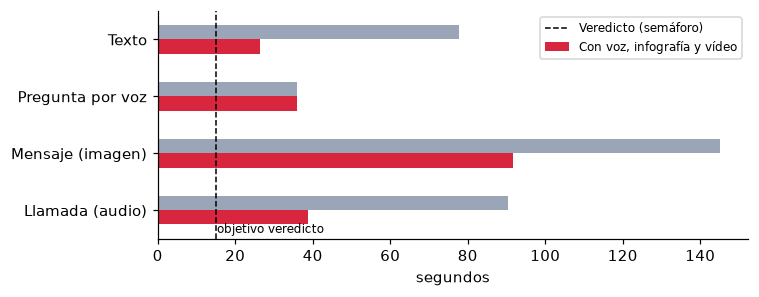

In [4]:
BENCH = config.ARTIFACTS_DIR / "benchmarks.json"
if BENCH.exists():
    bench = json.loads(BENCH.read_text(encoding="utf-8"))
    fuente = "medidas en el notebook 06"
else:
    bench = {"flujos": {"Mensaje (imagen)": {"veredicto_s": 12.0, "total_s": 40.0},
                        "Llamada (audio)": {"veredicto_s": 14.0, "total_s": 42.0},
                        "Texto": {"veredicto_s": 7.0, "total_s": 35.0}},
             "gpu_w": 115, "hardware": "RTX 4070 Laptop 8 GB (provisional)"}
    fuente = "PROVISIONALES (ejecutar antes el notebook 06)"
lat = pd.DataFrame(bench["flujos"]).T
display(Markdown(f"**Latencias por flujo ({fuente}) · hardware: {bench['hardware']}**"))
display(lat.round(1))

ax = lat[["veredicto_s", "total_s"]].plot.barh(figsize=(7, 2.8), color=["#d7263d", "#9aa5b8"])
ax.axvline(15, ls="--", c="k", lw=1)
ax.text(15.3, -0.4, "objetivo veredicto", fontsize=8)
ax.set_xlabel("segundos")
ax.legend(["Veredicto (semáforo)", "Con voz, infografía y vídeo"], fontsize=8)
plt.tight_layout()

ok = [f for f, v in bench["flujos"].items() if v["veredicto_s"] <= 15]
ko = [f for f, v in bench["flujos"].items() if v["veredicto_s"] > 15]
txt = f"**Lectura.** Cumplen el objetivo de 15 s: {', '.join(ok) or 'ninguno'}. "
if ko:
    txt += (f"No lo cumplen en este portátil: {', '.join(ko)}. El cuello de botella es la VRAM: con 8 GB, el modelo de "
            "visión y el LLM no caben a la vez y cada análisis de imagen obliga a descargar uno y cargar el otro. En un "
            "servidor con 24 GB ambos quedarían residentes y ese tiempo desaparece; mientras tanto, la interfaz muestra "
            "cada etapa en cuanto termina para que la espera no sea opaca.")
display(Markdown(txt))

## 5. Viabilidad económica: coste por análisis

Comparamos dos arquitecturas para el mismo flujo (imagen o llamada → veredicto → voz → infografía):

* **Local (la nuestra):** una GPU en el centro de datos del banco. El coste es la amortización de la
  máquina más la energía, repartidos entre los análisis.
* **APIs de pago equivalentes:** transcripción, LLM multimodal, TTS y generación de imagen por API.

Los precios de las APIs son **precios públicos aproximados (2025)** y están en un diccionario editable.

In [5]:
api_precios = {
    "ASR por minuto (USD)": 0.006,
    "LLM entrada por 1M tokens (USD)": 2.5,
    "LLM salida por 1M tokens (USD)": 10.0,
    "TTS por 1M caracteres (USD)": 15.0,
    "Imagen generada (USD)": 0.04,
}
consumo = {"minutos_audio": 1.0, "tokens_in": 2500 * 2, "tokens_out": 600 * 2, "chars_tts": 350, "imagenes": 1}
usd_eur = 0.92
coste_api = usd_eur * (
    consumo["minutos_audio"] * api_precios["ASR por minuto (USD)"]
    + consumo["tokens_in"] / 1e6 * api_precios["LLM entrada por 1M tokens (USD)"]
    + consumo["tokens_out"] / 1e6 * api_precios["LLM salida por 1M tokens (USD)"]
    + consumo["chars_tts"] / 1e6 * api_precios["TTS por 1M caracteres (USD)"]
    + consumo["imagenes"] * api_precios["Imagen generada (USD)"])

# Despliegue local: servidor con GPU de 24 GB que atiende análisis en serie.
servidor = {"precio_eur": 9000, "vida_anios": 3, "potencia_w": 450, "eur_kwh": 0.15, "uso_horas_dia": 24}
seg_por_analisis = float(np.mean([f["total_s"] for f in bench["flujos"].values()])) * 0.6  # GPU de servidor ≈ 40 % más rápida
analisis_max_anio = 3600 / seg_por_analisis * servidor["uso_horas_dia"] * 365
amort_anio = servidor["precio_eur"] / servidor["vida_anios"]
energia_por_analisis = servidor["potencia_w"] / 1000 * seg_por_analisis / 3600 * servidor["eur_kwh"]


def coste_local(analisis_anio: float) -> float:
    """Coste medio por análisis con un servidor (o varios si la demanda lo exige)."""
    n_serv = max(1, int(np.ceil(analisis_anio / analisis_max_anio)))
    return (n_serv * amort_anio) / analisis_anio + energia_por_analisis


tabla = pd.DataFrame({
    "Concepto": ["API de pago equivalente", "Local · 100.000 análisis/año", "Local · 1 M análisis/año", "Local · capacidad máxima de 1 servidor"],
    "€ por análisis": [coste_api, coste_local(1e5), coste_local(1e6), coste_local(analisis_max_anio)],
})
display(tabla.style.format({"€ por análisis": "{:.4f}"}).hide(axis="index"))
print(f"Capacidad de un servidor: {analisis_max_anio:,.0f} análisis/año ({seg_por_analisis:.1f} s por análisis)")

Concepto,€ por análisis
API de pago equivalente,0.0697
Local · 100.000 análisis/año,0.0310
Local · 1 M análisis/año,0.0070
Local · capacidad máxima de 1 servidor,0.0060


Capacidad de un servidor: 601,734 análisis/año (52.4 s por análisis)


**Lectura.** Con APIs de pago cada análisis cuesta unos 0.070 €; en local, a partir de ≈ 45,816 análisis al año (un banco mediano hace más de un millón, ver el escenario siguiente) el coste baja de ahí, y el coste **marginal** de un análisis adicional es solo la energía (0.00098 €). Y, sobre todo, **ningún audio ni captura del cliente sale del banco**, algo que con APIs externas obligaría a contratos de encargo de tratamiento y transferencias internacionales de datos.

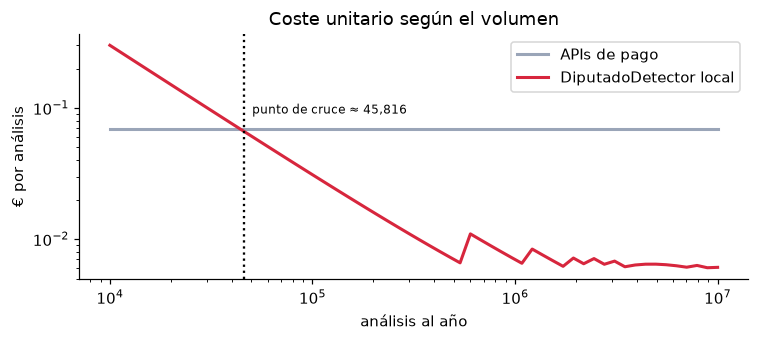

In [6]:
volumen = np.logspace(4, 7, 60)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(volumen, [coste_api] * len(volumen), label="APIs de pago", c="#9aa5b8", lw=2)
ax.plot(volumen, [coste_local(v) for v in volumen], label="DiputadoDetector local", c="#d7263d", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("análisis al año"); ax.set_ylabel("€ por análisis")
cruce = next((v for v in volumen if coste_local(v) < coste_api), None)
if cruce:
    ax.axvline(cruce, ls=":", c="k"); ax.text(cruce * 1.1, coste_api * 1.3, f"punto de cruce ≈ {cruce:,.0f}", fontsize=8)
ax.legend(); ax.set_title("Coste unitario según el volumen")
plt.tight_layout()

display(Markdown(
    f"**Lectura.** Con APIs de pago cada análisis cuesta unos {coste_api:.3f} €; en local, a partir de "
    f"≈ {cruce:,.0f} análisis al año (un banco mediano hace más de un millón, ver el escenario siguiente) "
    f"el coste baja de ahí, y el coste **marginal** de un análisis adicional es solo la energía "
    f"({energia_por_analisis:.5f} €). Y, sobre todo, **ningún audio ni captura del cliente sale del banco**, "
    "algo que con APIs externas obligaría a contratos de encargo de tratamiento y transferencias "
    "internacionales de datos." if cruce else
    "**Lectura.** Con estos supuestos la arquitectura local no compensa por coste en el rango estudiado; "
    "su ventaja es la privacidad: ningún dato del cliente sale del banco."))

## 6. Monetización y escenario de negocio

Proponemos una licencia SaaS al banco por **usuario activo mensual** (MAU) que usa el escudo, más una tarifa
anual de despliegue on-premise. El precio se ancla al ahorro: el banco paga una fracción del fraude que
evita (y que, con el PSR, tendría que reembolsar).

In [7]:
escenario = {
    "clientes_banco": 2_000_000,
    "adopcion": 0.08,                  # clientes que activan el escudo
    "analisis_por_mau_mes": 1.5,
    "precio_mau_mes_eur": 0.25,
    "tarifa_onprem_anual_eur": 60_000,
    "fraude_por_cliente_anual_eur": 4.0,  # pérdidas por fraude APP repartidas entre clientes (supuesto)
    "reduccion_fraude_usuarios": 0.30,    # parte del fraude evitada entre los usuarios activos (supuesto)
}
mau = escenario["clientes_banco"] * escenario["adopcion"]
analisis_anio = mau * escenario["analisis_por_mau_mes"] * 12
ingresos = mau * escenario["precio_mau_mes_eur"] * 12 + escenario["tarifa_onprem_anual_eur"]
coste_infra = analisis_anio * coste_local(analisis_anio)
ahorro_banco = mau * escenario["fraude_por_cliente_anual_eur"] * escenario["reduccion_fraude_usuarios"] * 3  # los usuarios activos son ~3x más objetivo
resumen = pd.Series({
    "Usuarios activos (MAU)": f"{mau:,.0f}",
    "Análisis al año": f"{analisis_anio:,.0f}",
    "Ingresos anuales DiputadoDetector": f"{ingresos:,.0f} €",
    "Coste de infraestructura (local)": f"{coste_infra:,.0f} €",
    "Coste si usáramos APIs": f"{analisis_anio * coste_api:,.0f} €",
    "Margen bruto": f"{(ingresos - coste_infra) / ingresos:.0%}",
    "Fraude evitado estimado para el banco": f"{ahorro_banco:,.0f} €",
    "ROI para el banco (ahorro / precio)": f"{ahorro_banco / ingresos:.1f}x",
})
display(resumen.to_frame("Escenario banco mediano (supuestos editables)"))

,Escenario banco mediano (supuestos editables)
Usuarios activos (MAU),"160,000"
Análisis al año,"2,880,000"
Ingresos anuales DiputadoDetector,"540,000 €"
Coste de infraestructura (local),"17,830 €"
Coste si usáramos APIs,"200,707 €"
Margen bruto,97%
Fraude evitado estimado para el banco,"576,000 €"
ROI para el banco (ahorro / precio),1.1x


## 7. Marco regulatorio

| Norma | Qué exige | Cómo lo abordamos |
|---|---|---|
| **RGPD** (y LOPDGDD) | Minimización, base legal, seguridad; voz e imagen son datos personales | Procesamiento 100 % local; enmascarado de IBAN, tarjetas, DNI y teléfonos antes de guardar (`extractors.mask_pii`); el histórico guarda resúmenes enmascarados |
| **PSD2 / PSD3 y PSR** | Autenticación reforzada; responsabilidad del banco en suplantación | El escudo refuerza el «momento de la verdad» (antes de dictar el OTP); regla dura: pedir un código siempre es rojo |
| **AI Act (Reglamento UE 2024/1689)** | La detección de fraude financiero está excluida expresamente de los sistemas de alto riesgo del anexo III (punto 5.b); obligaciones de transparencia del artículo 50 | Todo contenido generado (voz, infografía, vídeo) lleva la marca «Generado por IA»; decisiones explicables con la contribución de cada señal |
| **DORA** (Reglamento UE 2022/2554) | Resiliencia operativa digital y gestión del riesgo de terceros TIC | Sin dependencia de APIs externas: no hay proveedor crítico tercero; funciona sin internet |
| **Accesibilidad** (Ley 11/2023, Acta Europea de Accesibilidad) | Servicios bancarios accesibles desde 2025 | Salida por voz, botones grandes, alto contraste |

**Principio de diseño:** DiputadoDetector **aconseja, no bloquea**. La decisión final es del cliente; el
sistema no ejecuta acciones sobre la cuenta. Esto reduce el riesgo regulatorio y el impacto de un
falso positivo.

## 8. Riesgos y mitigaciones

In [8]:
riesgos = pd.DataFrame([
    ("Falsos positivos que generan desconfianza", "Media", "Alto", "Caso legítimo en la demo; umbrales calibrados en el notebook 05; nivel ámbar intermedio"),
    ("Estafadores que adaptan sus mensajes", "Alta", "Medio", "Base de campañas actualizable; LLM generalista + reglas; reentrenamiento de TacticNet en minutos"),
    ("Voces clonadas de última generación", "Alta", "Medio", "VozSinteticaNet solo puede subir el riesgo; el contenido (pide código) pesa más que la voz"),
    ("Hardware insuficiente en el banco", "Baja", "Medio", "Modo ligero en CPU (Whisper base, infografía de plantilla)"),
    ("Alucinaciones del LLM", "Media", "Medio", "Salida JSON validada; el LLM es una señal más en la fusión, no el árbitro"),
], columns=["Riesgo", "Probabilidad", "Impacto", "Mitigación"])
display(riesgos.style.hide(axis="index"))

Riesgo,Probabilidad,Impacto,Mitigación
Falsos positivos que generan desconfianza,Media,Alto,Caso legítimo en la demo; umbrales calibrados en el notebook 05; nivel ámbar intermedio
Estafadores que adaptan sus mensajes,Alta,Medio,Base de campañas actualizable; LLM generalista + reglas; reentrenamiento de TacticNet en minutos
Voces clonadas de última generación,Alta,Medio,VozSinteticaNet solo puede subir el riesgo; el contenido (pide código) pesa más que la voz
Hardware insuficiente en el banco,Baja,Medio,"Modo ligero en CPU (Whisper base, infografía de plantilla)"
Alucinaciones del LLM,Media,Medio,"Salida JSON validada; el LLM es una señal más en la fusión, no el árbitro"


## Conclusiones

* El problema es real, creciente y **multimodal por naturaleza**; la regulación (PSR) traslada su coste a
  los bancos, que son nuestros clientes.
* El modelo **B2B2C** combina el acceso del banco al cliente con su incentivo económico.
* La arquitectura **local** es más barata que las APIs a partir de un volumen modesto y, sobre todo,
  resuelve la privacidad y la dependencia de terceros (RGPD y DORA).
* La latencia medida en un portátil de 8 GB ya es usable, con un veredicto progresivo y salidas multimedia
  que llegan después; el único freno es la VRAM, y desaparece con una GPU de servidor.